# **6주차 강화학습 실습**

안녕하세요.

Tobig's 24기 서민정, 정서윤입니다.

본 실습은 3x4 그리드 월드(GridWorld) 환경에서 에이전트가 함정을 피하고 목표 지점에 도달하는 최적의 경로를 학습하는 과정을 다룹니다.

환경의 완벽한 정보를 안다고 가정하는 동적 계획법(DP)부터, 경험을 통해 학습하는 몬테카를로(MC)와 시간차 학습(TD) 알고리즘까지 순차적으로 구현해봅니다. 이를 통해 각 강화학습 알고리즘의 작동 원리를 깊이 이해하고, 실질적인 차이점을 비교 분석해보겠습니다.

# **3x4 그리드 월드**

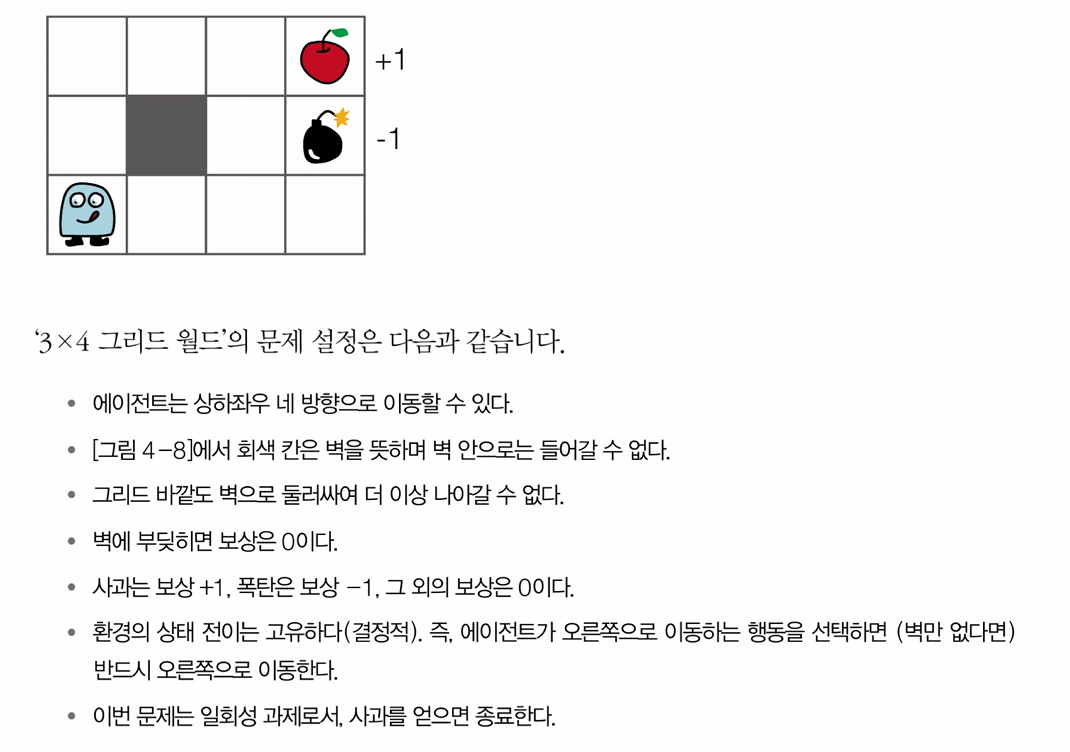

# **동적 프로그래밍(Dynamic Programming)**

동적 계획법은 환경의 전이 확률과 보상 함수를 모두 알고 있다는 가정 하에 동작합니다. 가치 반복(Value Iteration)은 벨만 최적 방정식을 업데이트 규칙으로 사용하여, 상태 가치 함수가 수렴할 때까지 반복 계산하여 최적 가치 함수와 최적 정책을 찾습니다.

**SETUP**

In [1]:
# install gridworld from pip
!pip install dezerogym

**1. 환경 초기화 및 무작위 가치 함수 시각화**

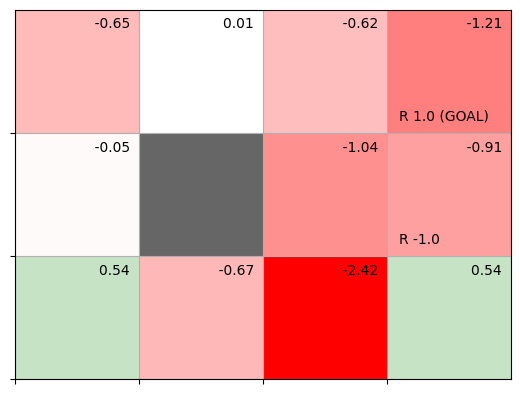

In [2]:
import numpy as np
from dezerogym.gridworld import GridWorld

env = GridWorld()
V = {}

for state in env.states():
    V[state] = np.random.randn()
env.render_v(V)

**2. 정책 평가 (Policy Evaluation)**

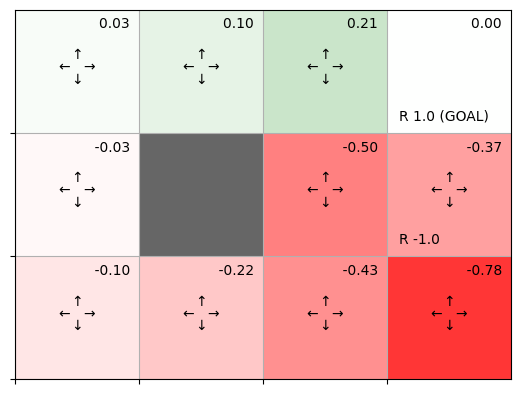

In [3]:
from collections import defaultdict
from dezerogym.gridworld import GridWorld


def eval_onestep(pi, V, env, gamma=0.9):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_probs = pi[state]
        new_V = 0
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V


def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy()
        V = eval_onestep(pi, V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

**3. 정책 반복 (Policy Iteration)**

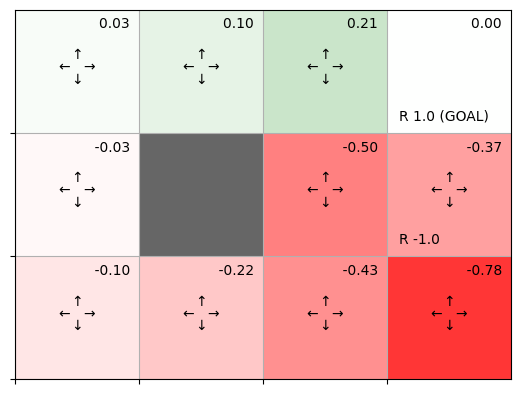

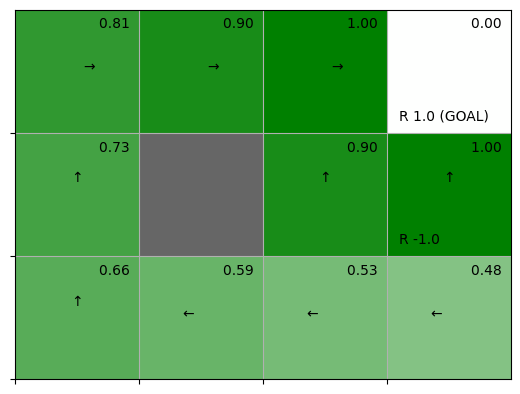

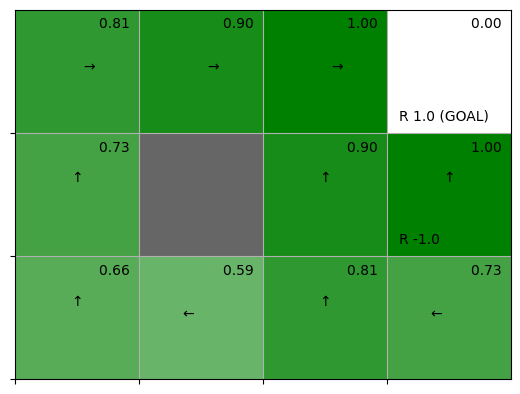

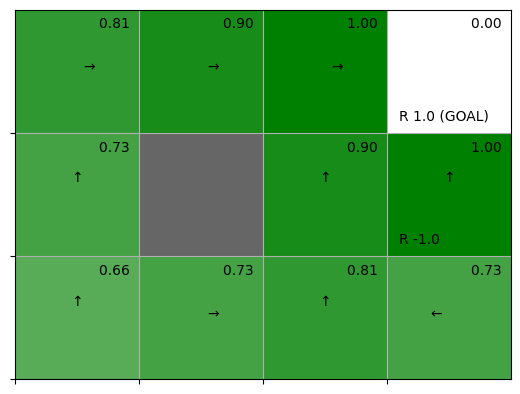

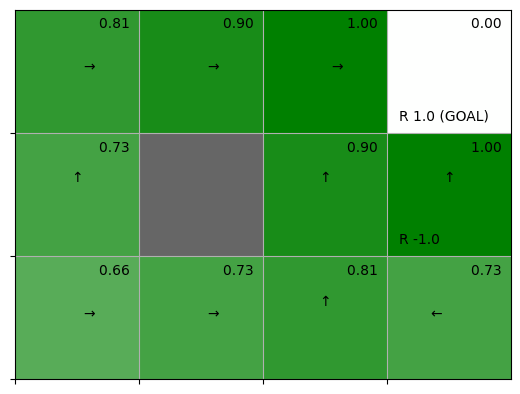

In [4]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key


def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi


def policy_iter(env, gamma, threshold=0.001, is_render=True):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi

    return pi


env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma)


**4. 가치 반복 (Value Iteration)**

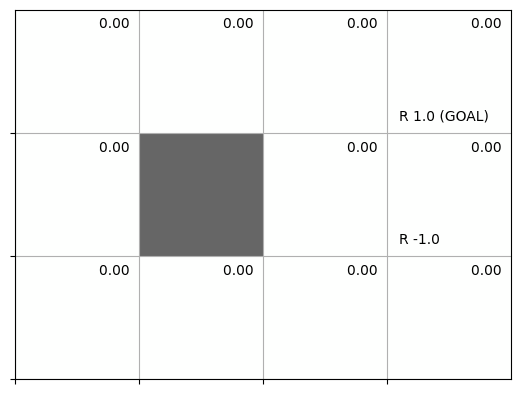

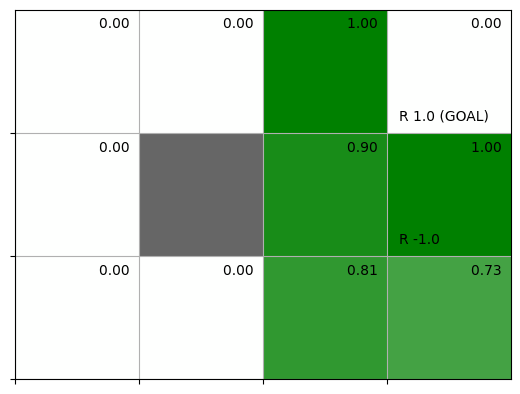

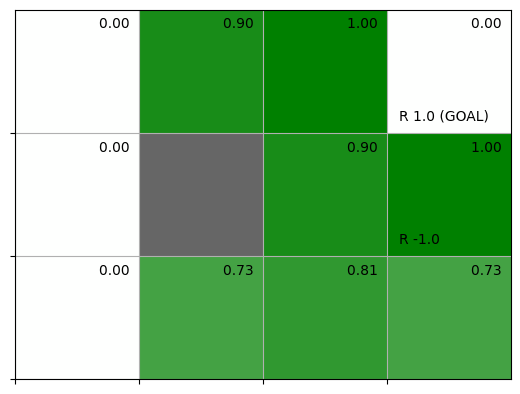

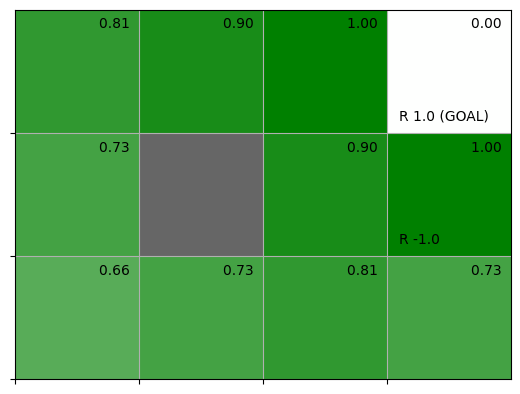

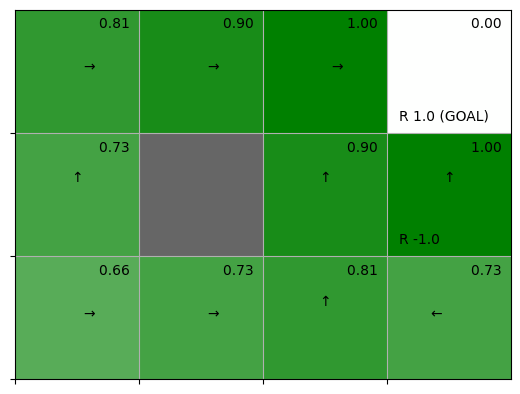

In [5]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values.append(value)

        V[state] = max(action_values)
    return V


def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)

        old_V = V.copy()
        V = value_iter_onestep(V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma)

pi = greedy_policy(V, env, gamma)
env.render_v(V, pi)

# **몬테카를로법(Monte Carlo Method)**

몬테카를로 방법은 환경의 모델을 모를 때, 에이전트가 직접 환경과 상호작용하며 얻은 에피소드(경험)를 바탕으로 학습합니다. 에피소드가 끝날 때까지 기다렸다가 실제 얻은 반환값을 사용하여 Q-함수를 업데이트합니다. 여기서 구현하는 비활성 정책(Off-policy) MC는 탐험을 위한 행동 정책(Behavior Policy)과 최적화하려는 목표 정책(Target Policy)을 분리하고 중요도 샘플링을 적용합니다.

**SETUP**

In [6]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld

**1. 무작위 에이전트를 이용한 MC 정책 평가**

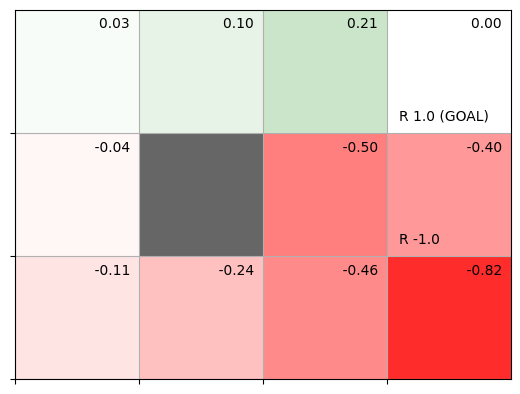

In [7]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):  # 역방향으로(reserved) 따라가기
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]


env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):  # 에피소드 1000번 수행
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)             # 행동 선택
        next_state, reward, done = env.step(action)  # 행동 수행

        agent.add(state, action, reward)  # (상태, 행동, 보상) 저장
        if done:   # 목표에 도달 시
            agent.eval()  # 몬테카를로법으로 가치 함수 갱신
            break         # 다음 에피소드 시작

        state = next_state

# 모든 에피소드 종료

# 가치 함수 시각화
env.render_v(agent.V)

**[공통 유틸리티] 엡실론-탐욕(epsilon-greedy) 확률 계산 함수**

In [8]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**2. 활성 정책 MC 제어 (On-Policy MC Control)**

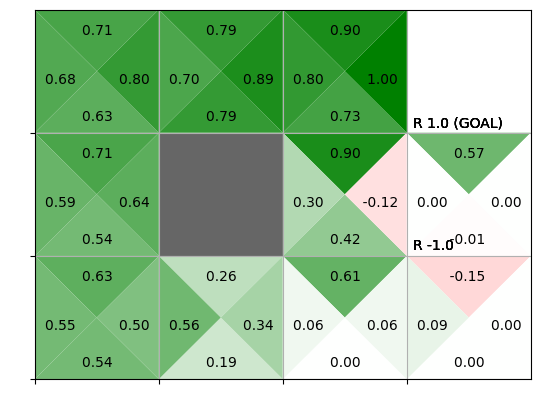

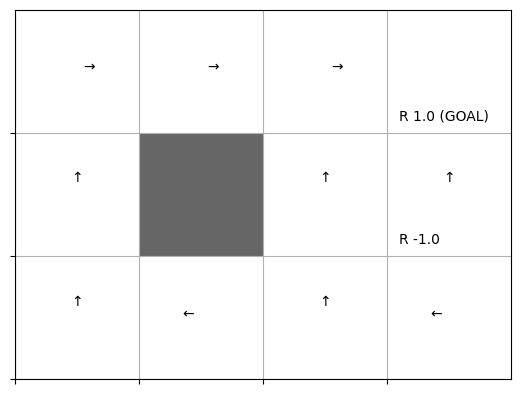

In [9]:
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1  # (첫 번째 개선) ε-탐욕 정책의 ε
        self.alpha = 0.1    # (두 번째 개선) Q 함수 갱신 시의 고정값 α
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        # self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            # self.cnts[key] += 1
            # self.Q[key] += (G - self.Q[key]) / self.cnts[key]
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 MC 제어 (Off-Policy MC Control)**

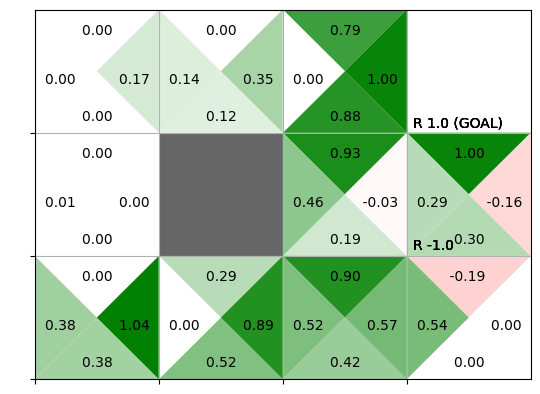

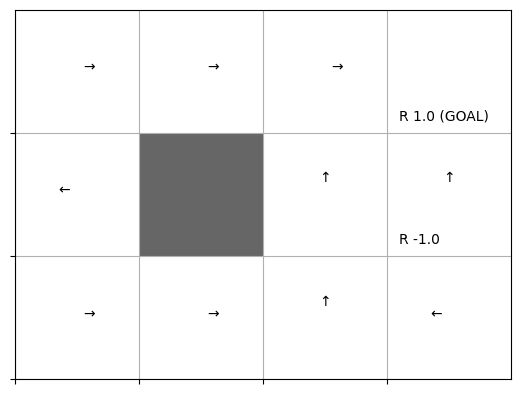

In [10]:
class McOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.2
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        rho = 1

        for data in reversed(self.memory):
            state, action, reward = data
            key = (state, action)

            G = self.gamma * rho * G + reward
            self.Q[key] += (G - self.Q[key]) * self.alpha
            rho *= self.pi[state][action] / self.b[state][action]

            self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
            self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

# **TD법(Temporal Difference Methods)**

시간차(TD) 학습은 MC와 마찬가지로 모델 없이 학습하지만, 에피소드가 끝날 때까지 기다리지 않고 매 타임스텝마다 학습합니다. Q-Learning은 TD의 대표적인 비활성 정책 제어 알고리즘으로, 다음 상태에서 가능한 가장 큰 Q-값을 다음 타겟으로 사용하여 현재 상태의 Q-값을 실시간으로 업데이트합니다.

**[공통 유틸리티 함수]**

In [11]:
# utility functions (common functions)
def argmax(xs):
    idxes = [i for i, x in enumerate(xs) if x == max(xs)]
    if len(idxes) == 1:
        return idxes[0]
    elif len(idxes) == 0:
        return np.random.choice(len(xs))
    selected = np.random.choice(idxes)
    return selected

def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = argmax(qs)  # OR np.argmax(qs)
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**1. TD 정책 평가 (TD Evaluation)**

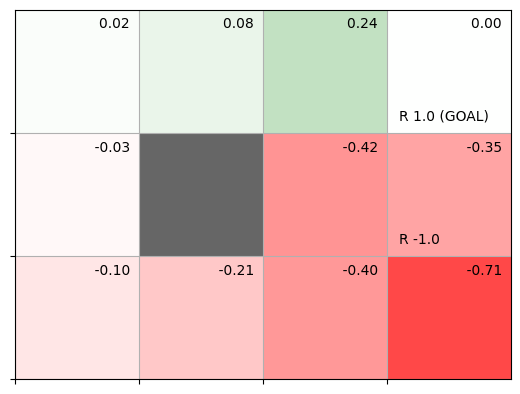

In [12]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld


class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V
        self.V[state] += (target - self.V[state]) * self.alpha


env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

**2. SARSA (활성 정책 TD 제어, On-Policy TD Control)**

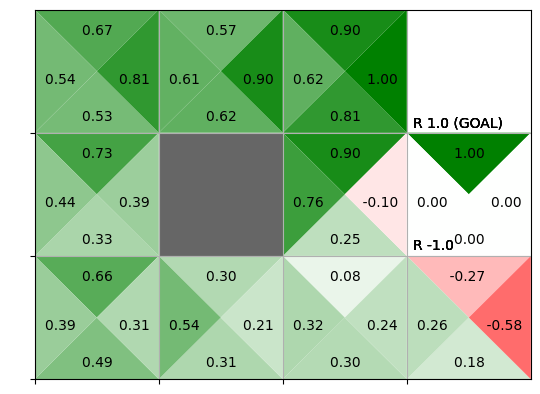

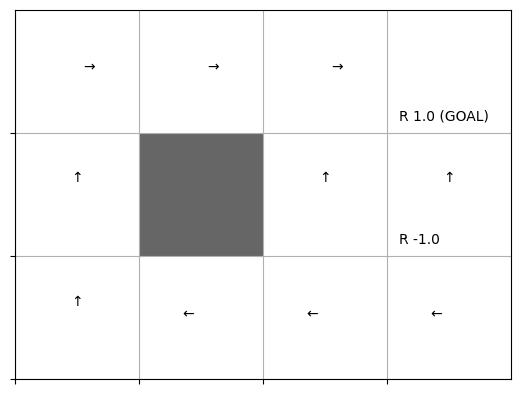

In [13]:
from collections import deque


class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]
        next_q = 0 if done else self.Q[next_state, next_action]

        target = reward + self.gamma * next_q
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 SARSA (Off-Policy SARSA)**

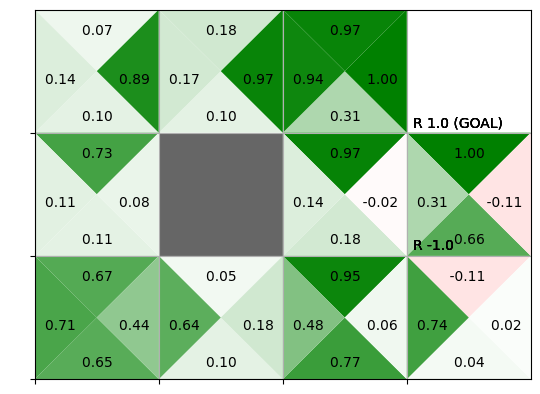

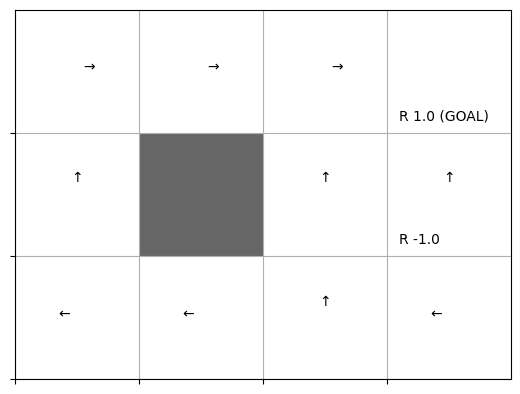

In [14]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, 0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**4. Q-Learning (버전 1: 목표 정책 pi와 행동 정책 b 명시적 분리)**

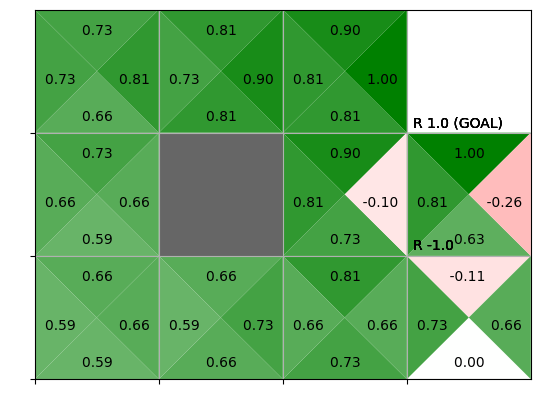

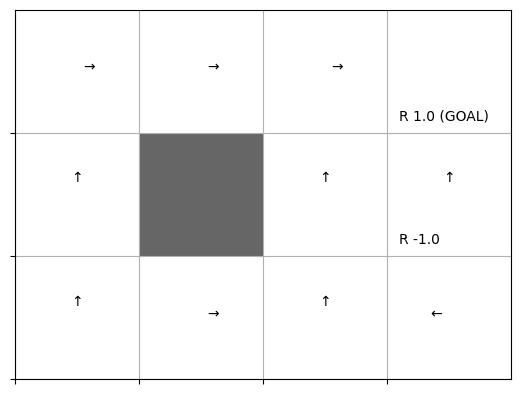

In [15]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

**5. Q-Learning (버전 2: 딕셔너리로 b와 pi를 유지하지 않고, get_action에서 즉석으로 엡실론-탐욕을 계산하여 메모리와 연산을 최적화)**

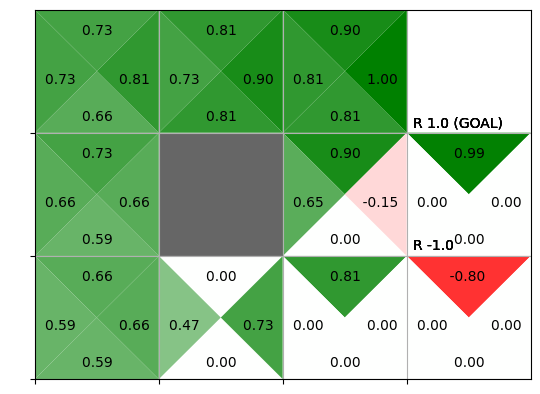

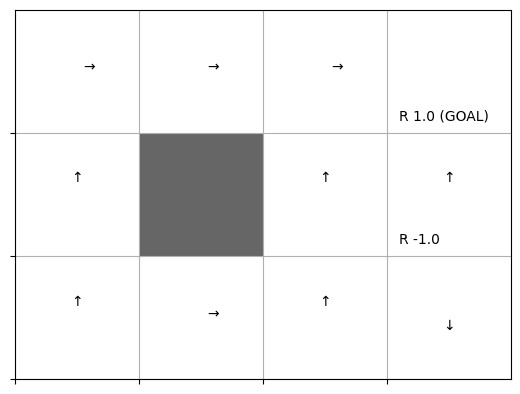

In [16]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[state, a] for a in range(self.action_size)]
            return np.argmax(qs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

# **결과 분석 및 서술형 문제**

■ 과제 수행 방법:

DP, MC, TD의 모든 에이전트 코드를 순서대로 실행해보십시오. 각 학습이 완료된 후 출력되는 그리드월드 상의 가치(Value) 또는 Q-값(상태-행동 가치)과 에이전트의 정책 방향 화살표를 주의 깊게 관찰한 뒤, 아래의 질문에 대해 서술형으로 답안을 작성하여 제출 바랍니다.

**[문제 1]**

동적 계획법(DP)의 value_iter 코드와 시간차 학습(TD)의 QLearningAgent 코드를 비교해 보십시오.

DP는 에피소드를 진행하며 환경과 상호작용할 필요 없이 가치를 계산할 수 있었습니다. 그 이유(DP의 전제 조건)가 무엇인지 설명하고, 자율주행이나 주식 거래와 같은 현실 세계의 복잡한 문제에서 DP 대신 MC나 TD와 같은 모델 프리(Model-free) 알고리즘을 사용해야만 하는 이유를 서술하시오.

답안: DP가 환경과 직접 상호작용 없이 가치를 계산할 수 있는 이유는 환경의 완벽한 모델을 사전에 알고 있다는 전제가 있기 때문입니다. 여기서 모델이란 에이전트가 특정 상태에서 특정 행동을 취했을 때 다음 상태로 전이될 확률과 그때 받을 보상에 대한 정확한 보상 함수를 의미합니다. DP의 코드 로직을 보면 환경의 다음 상태와 보상을 직접 조회하며 계산하는 것을 확인할 수 있습니다.

반면 자율주행이나 주식 거래와 같은 현실 세계의 복잡한 문제에서는 DP를 적용하기 어렵습니다. 현실 문제는 상태와 행동의 공간이 무한에 가깝거나 연속적이며, 환경의 변화가 매우 복잡하고 불확실하여 완벽한 모델을 구축하는 것이 불가능합니다. 따라서 환경의 모델을 모르는 상태에서도 에이전트가 직접 상호작용하며 학습하는 모델 프리 알고리즘인 MC나 TD를 사용해야만 합니다.

**[문제 2]**

몬테카를로 제어(McAgent)와 시간차 제어(SarsaAgent) 코드를 보면 에이전트의 가치(self.Q)를 업데이트하는 시점(메서드 호출 시점)이 다릅니다.

1. 두 알고리즘이 각각 어느 시점에 가치를 업데이트하는지 코드를 바탕으로 설명하시오.

2. 이러한 업데이트 시점의 차이로 인해 발생하는 장단점(학습 속도, 편향과 분산 등)을 비교하여 서술하시오.

답안:

1. 몬테카를로 제어(McAgent)와 시간차 제어(SarsaAgent)는 가치를 업데이트하는 주기에 결정적인 차이가 있습니다. 몬테카를로 제어 코드를 보면 에피소드가 끝날 때까지 데이터를 메모리에 축적만 하다가, 종료 시점에 한 번에 에피소드 전체의 반환값을 바탕으로 가치를 갱신합니다. 반면 시간차 제어는 매 타임스텝마다 행동을 수행한 직후 실시간으로 가치를 갱신합니다.

2. 이러한 업데이트 시점의 차이로 학습 속도 측면에서 MC는 에피소드가 끝나야만 학습이 가능하므로 진행이 느리며 종료 상태가 없는 연속적 과제에는 적용할 수 없습니다. 반면 SARSA는 매 스텝 학습하므로 목표 도달 전에도 중간 상태들의 가치를 교정할 수 있어 초기 학습 속도가 상대적으로 빠릅니다. 편향과 분산 측면에서 MC는 실제로 얻은 보상의 총합을 사용하므로 편향이 없는 추정이 가능하지만 긴 에피소드 동안 발생하는 무작위한 결과가 누적되어 분산이 매우 높습니다. 반면 SARSA는 다음 상태의 예측값을 활용하는 부트스트래핑 기법을 사용하여 편향이 발생할 수 있으나 분산은 MC보다 훨씬 낮아 학습이 안정적입니다.

**[문제 3]**

TD 학습 파트에서 SarsaAgent(활성 정책)와 QLearningAgent(비활성 정책)의 update 메서드 내부를 살펴보면, TD 타겟(Target)을 계산하는 방식에 핵심적인 차이가 있습니다.

1. SARSA는 타겟 계산을 위해 다음 상태의 어떤 값을 참조하며, Q-Learning은 어떤 값을 참조하는지 코드의 구체적인 변수명이나 로직을 들어 설명하시오.

2. 이 차이로 인해 그리드월드의 '함정' 근처에서 두 에이전트가 학습하는 최적 경로(안전 추구 vs. 최단 경로 추구)가 어떻게 달라질 수 있는지 추론하여 서술하시오.

답안:
1. TD 타겟을 계산할 때 참조하는 값에서 두 알고리즘의 차이가 발생합니다. 활성 정책인 SARSA는 다음 상태에서 실제 선택된 다음 행동의 Q값을 참조하여 타겟을 계산합니다. 비활성 정책인 Q-Learning은 실제로 어떤 행동을 할지와 무관하게 다음 상태에서 가장 높은 Q값, 즉 최적 행동의 가치를 참조하여 타겟을 계산합니다.

2. 이러한 차이로 인해 함정 근처에서 학습되는 최적 경로가 달라집니다. SARSA는 에이전트가 탐험을 하다가 실수로 함정에 빠질 가능성까지 고려하여 가치를 평가하므로, 함정 근처 상태의 가치를 낮게 평가하게 되고 결과적으로 함정에서 멀리 떨어진 우회로를 학습하게 됩니다. 반면 Q-Learning은 다음 상태에서 항상 최선의 선택을 할 것이라고 가정하고 가치를 업데이트하므로, 탐험 중 실수할 위험을 무시하고 목표 지점으로 향하는 최단 경로를 적극적으로 학습합니다.

**[문제 4]**

McOffPolicyAgent 및 SarsaOffPolicyAgent 코드를 보면, 직접 행동을 결정하는 정책(self.b)과 궁극적으로 최적화하려는 목표 정책(self.pi) 두 가지를 분리하여 운영합니다.

1. 왜 하나의 정책으로만 학습하지 않고 굳이 두 개의 정책을 분리해서 학습하는지 '탐험(Exploration)과 활용(Exploitation)의 딜레마' 관점에서 설명하시오.

2. 비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율인 rho($\rho$)를 곱해줍니다. 이 비율을 곱해주는 수학적/논리적 이유가 무엇인지 서술하시오.

답안:
1. 하나의 정책만으로 강화학습을 진행하면 탐험과 활용의 딜레마에 빠지게 됩니다. 에이전트가 최적의 행동을 찾으려면 다양한 경로를 탐험해야 하지만, 동시에 현재까지 알아낸 가장 좋은 경로를 활용해야 합니다. 이를 해결하기 위해 오프폴리시 방법은 무작위성이 포함되어 다양한 경험을 쌓는 행동 정책과 오직 최대 가치만을 쫓아 최적 경로를 수렴시키는 목표 정책을 분리합니다. 이를 통해 충분한 탐험을 보장하면서도 완전한 탐욕 정책을 안전하게 학습할 수 있습니다.

2. 비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율인 $\rho$를 곱해주는 이유는 데이터의 확률 분포를 보정하기 위함입니다. 에이전트는 행동 정책을 따르며 데이터를 수집했지만 우리가 평가하려는 대상은 목표 정책입니다. 수집된 보상 정보 그대로 가치를 업데이트하면 수학적 기댓값이 왜곡되므로, 행동 정책과 목표 정책 간의 발생 확률 차이를 가중치로 보정하여 올바른 가치 함수로 수렴하도록 만듭니다.

**[문제 5]**

실습에 사용된 그리드월드의 보상 체계를 변경한다고 가정해 봅시다. 현재는 도착 지점에 도달하면 +1, 함정에 빠지면 -1의 보상을 받습니다.

만약 에이전트가 가능한 한 빨리 목적지에 도달하도록 유도하기 위해, 매 스텝 이동할 때마다 -0.01의 페널티 보상을 주도록 환경(Environment)을 변경한다면, 학습이 완료된 후의 최적 정책(화살표 방향)과 가치 함수는 기존과 비교하여 어떤 식으로 변할지 예상하여 논리적으로 서술하시오.

답안: 매 스텝마다 -0.01의 페널티가 주어지는 환경으로 변경되면, 에이전트는 이동 횟수가 늘어날수록 페널티가 누적되기 때문에 어떻게든 '최단 거리'로 목적지에 도달하려는 강한 성향을 띠게 됩니다. 이로 인해 기존처럼 함정을 피하기 위해 멀리 돌아가던 안전 위주의 우회 경로는 모두 도태되고, 설령 함정 바로 옆을 지나갈 위험을 감수하더라도 가장 빠르게 목적지에 도달하는 과감한 직진 경로를 최적 정책으로 학습하게 됩니다. 가치 함수 역시 목적지에서 멀어질수록 감수해야 할 누적 페널티가 커지기 때문에, 거리에 반비례하여 가치가 가파르게 하락하는 뚜렷한 등고선 형태를 띠게 됩니다.

수고하셨습니다.